# OffScript — Phase 1: Initial Data Exploration

This notebook pulls and explores Statcast pitch-by-pitch data for a curated set of MLB pitchers across the 2023 and 2024 seasons.

**Goals:**
- Retrieve raw Statcast data via `pybaseball` for two pitchers (Gerrit Cole, Dylan Cease)
- Trim the dataset to the columns relevant for pitch selection modeling
- Engineer two context features: count state and score differential
- Produce initial visualizations of pitch usage, location, and count-state behavior
- Save processed data for use in Phase 2

**Output:** `data/processed/pitcher_data.parquet`

## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pybaseball import statcast_pitcher, playerid_lookup, cache

# Prevent re-downloading Statcast data on every run
cache.enable()

print("Imports successful")

Imports successful


## 2. Data Retrieval

MLBAM player IDs are looked up once via `playerid_lookup` and then hardcoded
below for reproducibility. Statcast data covers the full 2023 and 2024 regular
seasons plus postseason.

In [2]:
# Confirm MLBAM ID for Gerrit Cole
cole_lookup = playerid_lookup("Cole", "Gerrit")
print(cole_lookup[["name_last", "name_first", "key_mlbam"]])

Gathering player lookup table. This may take a moment.
  name_last name_first  key_mlbam
0      cole     gerrit     543037


In [3]:
# Gerrit Cole — MLBAM ID confirmed via playerid_lookup above
COLE_ID = 543037
DATE_START = "2023-03-30"
DATE_END = "2024-11-01"

print("Pulling Statcast data for Gerrit Cole...")
cole_data = statcast_pitcher(DATE_START, DATE_END, COLE_ID)

print(f"Total pitches: {len(cole_data)}")
print(f"Date range:    {cole_data['game_date'].min()} to {cole_data['game_date'].max()}")
print(f"Columns:       {len(cole_data.columns)}")

Pulling Statcast data for Gerrit Cole...
Gathering Player Data
Total pitches: 5318
Date range:    2023-03-30 to 2024-10-30
Columns:       118


## 3. Column Selection and Feature Engineering

Statcast returns ~90 columns. We retain only the subset relevant to pitch
selection modeling and engineer two context features:

- **`count`** — ball-strike count state (e.g. `'1-2'`), the primary conditioning
  variable for the Phase 2 model
- **`score_diff`** — home minus away score at time of pitch, used as a game
  context feature

In [4]:
COLS_OF_INTEREST = [
    "game_date",
    "pitcher",
    "player_name",
    "pitch_type",
    "pitch_name",
    "release_speed",
    "pfx_x", "pfx_z",
    "plate_x", "plate_z",
    "balls", "strikes",
    "on_1b", "on_2b", "on_3b",
    "stand",
    "p_throws",
    "events",
    "description",
    "inning",
    "home_score",
    "away_score",
]

cole_trimmed = cole_data[COLS_OF_INTEREST].copy()

# Count state: combine balls and strikes into a single string label
cole_trimmed["count"] = (
    cole_trimmed["balls"].astype(str) + "-" + cole_trimmed["strikes"].astype(str)
)

# Score differential: positive = home team leading
cole_trimmed["score_diff"] = cole_trimmed["home_score"] - cole_trimmed["away_score"]

print(cole_trimmed.shape)
print(cole_trimmed.dtypes)

(5318, 24)
game_date            str
pitcher            int64
player_name          str
pitch_type           str
pitch_name           str
release_speed    float64
pfx_x            float64
pfx_z            float64
plate_x          float64
plate_z          float64
balls              int64
strikes            int64
on_1b            float64
on_2b            float64
on_3b            float64
stand                str
p_throws             str
events               str
description          str
inning             int64
home_score         int64
away_score         int64
count                str
score_diff         int64
dtype: object


## 4. Exploratory Data Analysis

In [5]:
print("=== Pitch Type Distribution ===")
print(cole_trimmed["pitch_type"].value_counts())

print("\n=== Count State Distribution ===")
print(cole_trimmed["count"].value_counts().sort_index())

print("\n=== Batter Handedness ===")
print(cole_trimmed["stand"].value_counts())

print("\n=== Missing Values ===")
missing = cole_trimmed.isnull().sum()
print(missing[missing > 0])

=== Pitch Type Distribution ===
pitch_type
FF    2659
SL     984
KC     767
FC     530
CH     327
SI      39
Name: count, dtype: int64

=== Count State Distribution ===
count
0-0    1347
0-1     742
0-2     385
1-0     441
1-1     527
1-2     537
2-0     147
2-1     259
2-2     504
3-0      42
3-1      91
3-2     296
Name: count, dtype: int64

=== Batter Handedness ===
stand
L    2808
R    2510
Name: count, dtype: int64

=== Missing Values ===
pitch_type         12
pitch_name         12
release_speed       9
pfx_x               9
pfx_z               9
plate_x            12
plate_z            12
on_1b            3927
on_2b            4569
on_3b            4969
events           3972
dtype: int64


## 5. Visualizations

Three chart types are produced here to establish baseline intuitions about
Cole's pitch selection patterns. These are exploratory — the polished versions
used in the final analysis live in `src/pitch_analysis.py`.

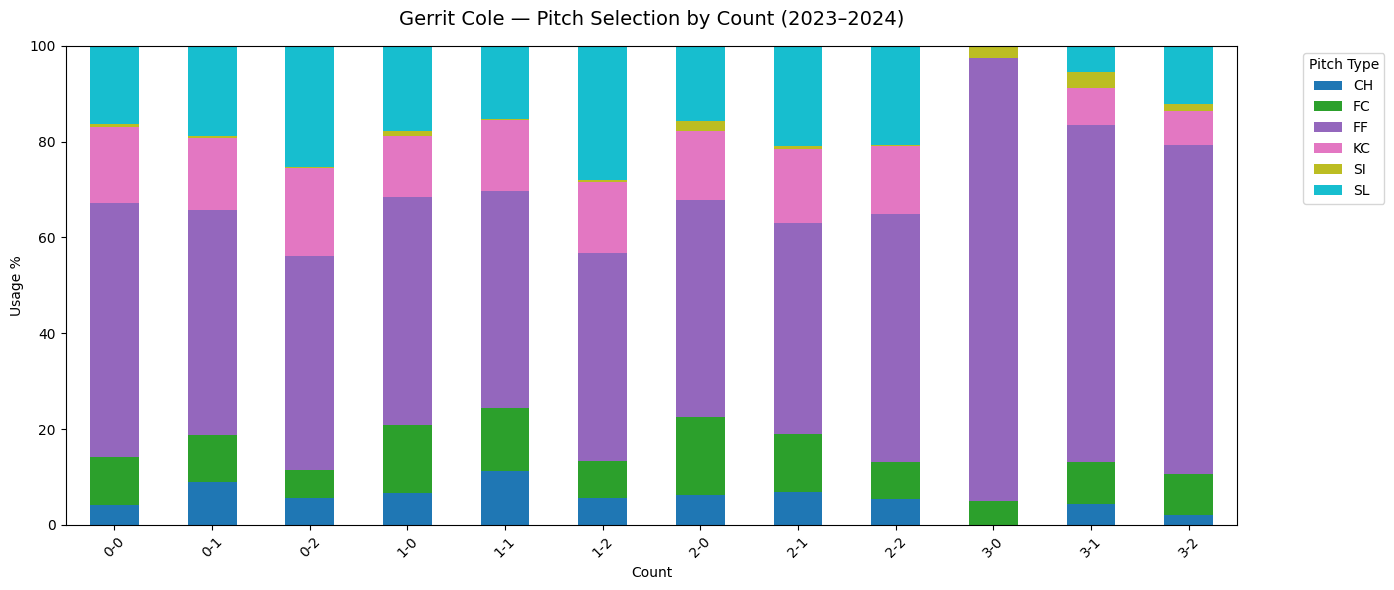

Saved: reports/figures/cole_pitch_selection_by_count.png


In [6]:
# --- Pitch selection by count state ---
count_pitch = (
    cole_trimmed.groupby(["count", "pitch_type"])
    .size()
    .reset_index(name="n")
)
count_pitch["pct"] = count_pitch.groupby("count")["n"].transform(
    lambda x: x / x.sum() * 100
)

fig, ax = plt.subplots(figsize=(14, 6))
pivot = (
    count_pitch.pivot(index="count", columns="pitch_type", values="pct")
    .fillna(0)
)
pivot.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")

ax.set_title("Gerrit Cole — Pitch Selection by Count (2023–2024)", fontsize=14, pad=15)
ax.set_ylabel("Usage %")
ax.set_xlabel("Count")
ax.legend(title="Pitch Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../reports/figures/cole_pitch_selection_by_count.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: reports/figures/cole_pitch_selection_by_count.png")

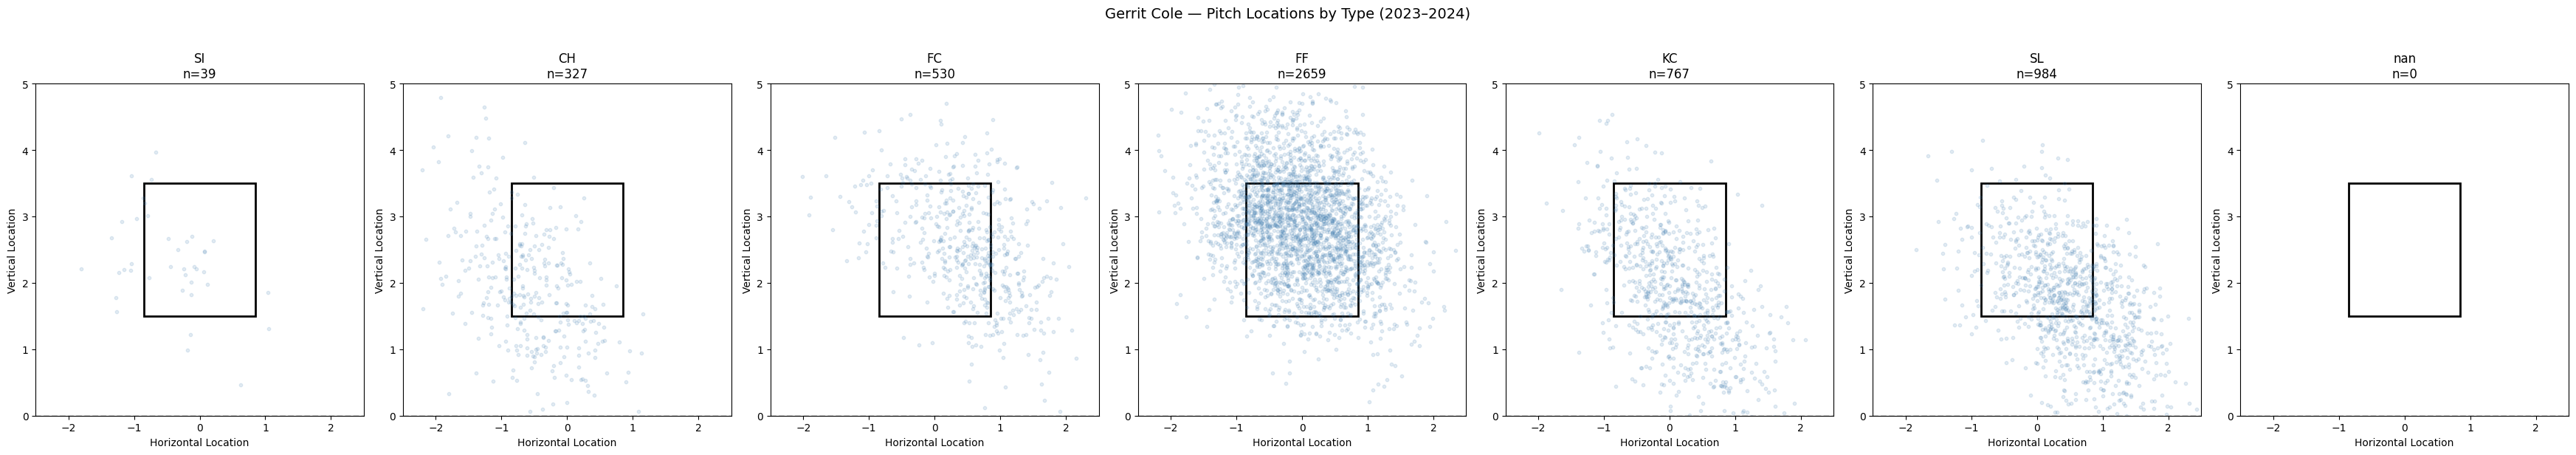

In [7]:
# --- Pitch location scatter by pitch type ---
def plot_pitch_locations(data: pd.DataFrame, pitcher_name: str, pitch_types: list | None = None) -> None:
    """Plot pitch location scatter plots by pitch type.

    Exploratory version used in Phase 1. The production version of this
    function lives in src/pitch_analysis.py.

    Args:
        data: Pitch-level DataFrame for a single pitcher.
        pitcher_name: Pitcher's full name, used for the figure title and filename.
        pitch_types: Optional list of pitch type codes to include. If None,
            all pitch types in the data are plotted.
    """
    if pitch_types:
        data = data[data["pitch_type"].isin(pitch_types)]

    pitches = data["pitch_type"].unique()
    n = len(pitches)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 6))
    if n == 1:
        axes = [axes]

    for ax, pitch in zip(axes, pitches):
        subset = data[data["pitch_type"] == pitch]

        zone = patches.Rectangle(
            (-0.85, 1.5), 1.7, 2.0,
            linewidth=2, edgecolor="black", facecolor="none",
        )
        ax.add_patch(zone)
        ax.scatter(subset["plate_x"], subset["plate_z"], alpha=0.15, s=10, color="steelblue")
        ax.set_xlim(-2.5, 2.5)
        ax.set_ylim(0, 5)
        ax.set_title(f"{pitch}\nn={len(subset)}")
        ax.set_xlabel("Horizontal Location")
        ax.set_ylabel("Vertical Location")
        ax.axhline(y=0, color="gray", linestyle="--", alpha=0.3)

    fig.suptitle(f"{pitcher_name} — Pitch Locations by Type (2023–2024)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(
        f"../reports/figures/{pitcher_name.lower().replace(' ', '_')}_locations.png",
        dpi=150, bbox_inches="tight",
    )
    plt.show()


plot_pitch_locations(cole_trimmed, "Gerrit Cole")

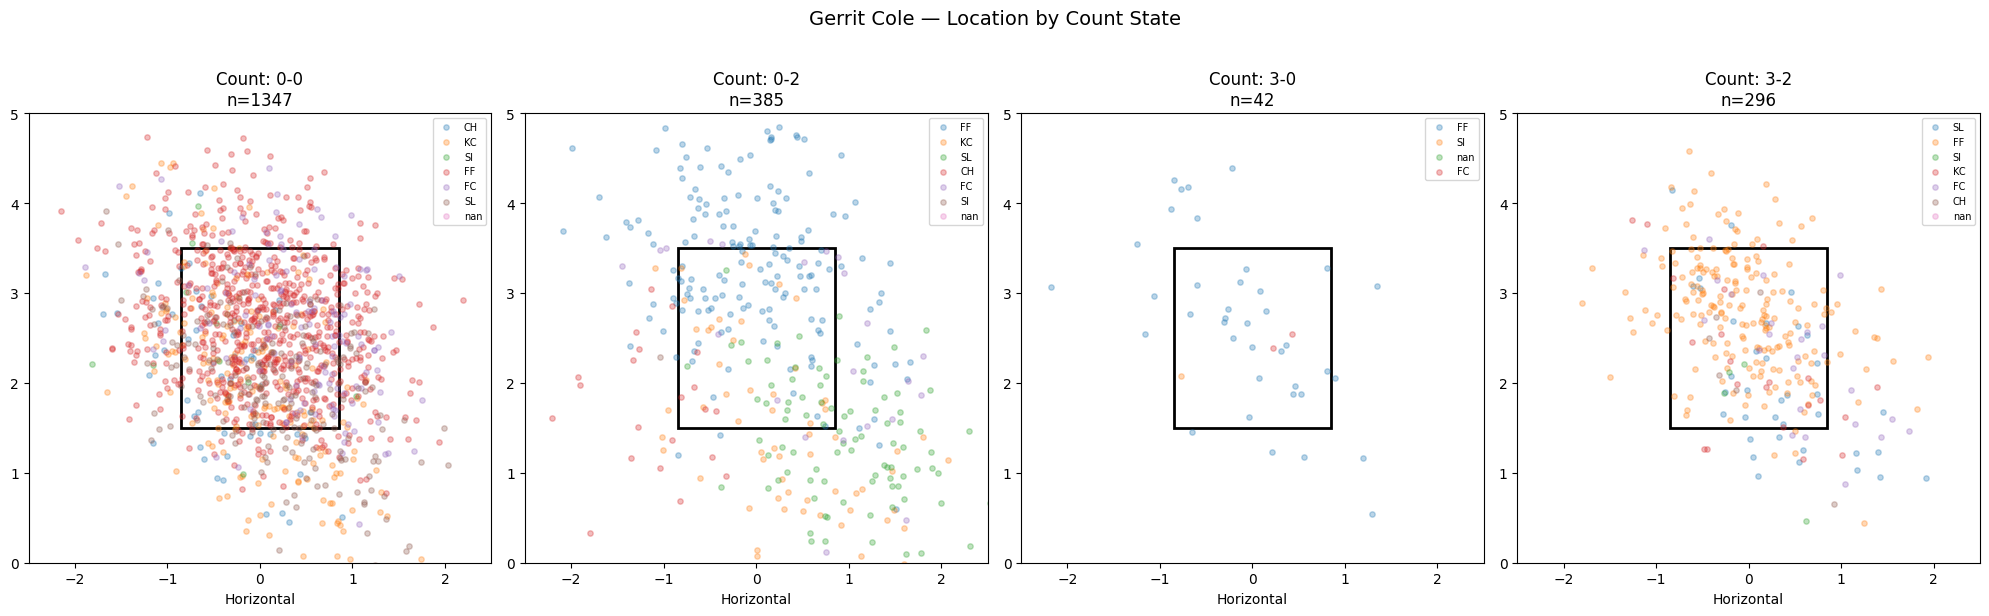

In [8]:
# --- Pitch location by count state ---
def plot_location_by_count(
    data: pd.DataFrame,
    pitcher_name: str,
    counts: list | None = None,
) -> None:
    """Plot pitch locations colored by pitch type for selected count states.

    Args:
        data: Pitch-level DataFrame for a single pitcher.
        pitcher_name: Pitcher's full name, used for the figure title and filename.
        counts: List of count state strings to plot (e.g. ['0-0', '3-2']).
            Defaults to four strategically distinct counts if not provided.
    """
    if counts is None:
        counts = ["0-0", "0-2", "3-0", "3-2"]

    fig, axes = plt.subplots(1, len(counts), figsize=(5 * len(counts), 6))

    for ax, count in zip(axes, counts):
        subset = data[data["count"] == count]

        zone = patches.Rectangle(
            (-0.85, 1.5), 1.7, 2.0,
            linewidth=2, edgecolor="black", facecolor="none",
        )
        ax.add_patch(zone)

        for pitch, color in zip(subset["pitch_type"].unique(), plt.cm.tab10.colors):
            p = subset[subset["pitch_type"] == pitch]
            ax.scatter(p["plate_x"], p["plate_z"], alpha=0.3, s=15, label=pitch, color=color)

        ax.set_xlim(-2.5, 2.5)
        ax.set_ylim(0, 5)
        ax.set_title(f"Count: {count}\nn={len(subset)}")
        ax.set_xlabel("Horizontal")
        ax.legend(fontsize=7)

    fig.suptitle(f"{pitcher_name} — Location by Count State", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(
        f"../reports/figures/{pitcher_name.lower().replace(' ', '_')}_location_by_count.png",
        dpi=150, bbox_inches="tight",
    )
    plt.show()


plot_location_by_count(cole_trimmed, "Gerrit Cole")

## 6. Dylan Cease — Second Pitcher

Cease is included as a strong deviation candidate due to his extreme slider
reliance. His data is retrieved and trimmed using the same pipeline as Cole.

In [9]:
# Dylan Cease — MLBAM ID 656302
CEASE_ID = 656302

print("Pulling Statcast data for Dylan Cease...")
cease_data = statcast_pitcher(DATE_START, DATE_END, CEASE_ID)

cease_trimmed = cease_data[COLS_OF_INTEREST].copy()
cease_trimmed["count"] = (
    cease_trimmed["balls"].astype(str) + "-" + cease_trimmed["strikes"].astype(str)
)
cease_trimmed["score_diff"] = cease_trimmed["home_score"] - cease_trimmed["away_score"]

print(f"Total pitches: {len(cease_trimmed)}")
print("\n=== Cease Pitch Distribution ===")
print(cease_trimmed["pitch_type"].value_counts())

Pulling Statcast data for Dylan Cease...
Gathering Player Data
Total pitches: 6722

=== Cease Pitch Distribution ===
pitch_type
FF    2875
SL    2706
KC     765
ST     151
CH     127
FC      19
SI       2
Name: count, dtype: int64
